In [1]:
%pip install pandas numpy matplotlib seaborn pydicom torch transformers streamlit scikit-learn opencv-python fpdf langchain email-validator tensorflow



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
# Cell 2: Import libraries
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm
from IPython.display import clear_output
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Concatenate, Input
from transformers import CLIPProcessor, CLIPModel
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import torch.nn.functional as F
# Completely ignore all warnings
warnings.filterwarnings("ignore")

In [3]:
MyDrive = './Datas'
clear_output()

In [5]:
PneumoniaDir = './Datas/chest-xray-pneumonia/chest_xray'
print('> Pneumonia dir:', os.listdir(PneumoniaDir))

> Pneumonia dir: ['.DS_Store', 'test', 'train', 'val']


In [6]:
train_image_dir = os.path.join(PneumoniaDir, 'train')
test_image_dir  = os.path.join(PneumoniaDir, 'test')
val_image_dir   = os.path.join(PneumoniaDir, 'val') 

In [7]:
# Build a list mapping image paths to their labels
img_map = []

def prepareData(Dir, strat):
    cats = ["NORMAL", "PNEUMONIA"]
    if not os.path.exists(Dir):
        print(f"Warning: Directory {Dir} does not exist. Skipping...")
        return
    for category in cats:
        path = os.path.join(Dir, category)
        if not os.path.exists(path):
            print(f"Warning: Category {category} not found in {Dir}. Skipping...")
            continue
        for img in tqdm(os.listdir(path), desc=f"Processing {category} in {strat}"):
            img_path = os.path.join(path, img)
            # Filter only image files
            if img.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_map.append({'path': img_path, 'label': category})
            else:
                print(f"Skipping non-image file: {img_path}")

# Process each dataset split
prepareData(train_image_dir, 'train')
prepareData(test_image_dir, 'test')
prepareData(val_image_dir, 'val')

Processing NORMAL in train: 100%|██████████| 1342/1342 [00:00<00:00, 257502.90it/s]


Skipping non-image file: ./Datas/chest-xray-pneumonia/chest_xray\train\NORMAL\.DS_Store


Processing PNEUMONIA in train:   0%|          | 0/3876 [00:00<?, ?it/s]

Processing PNEUMONIA in train: 100%|██████████| 3876/3876 [00:00<00:00, 242339.79it/s]


Skipping non-image file: ./Datas/chest-xray-pneumonia/chest_xray\train\PNEUMONIA\.DS_Store


Processing NORMAL in val: 100%|██████████| 9/9 [00:00<?, ?it/s]


Skipping non-image file: ./Datas/chest-xray-pneumonia/chest_xray\val\NORMAL\.DS_Store


Processing PNEUMONIA in val: 100%|██████████| 9/9 [00:00<00:00, 6179.20it/s]

Skipping non-image file: ./Datas/chest-xray-pneumonia/chest_xray\val\PNEUMONIA\.DS_Store


In [8]:
# Shuffle and convert to DataFrame
seed_shuffle = 42
img_map = pd.DataFrame(img_map).sample(frac=1, random_state=seed_shuffle)
print(img_map.head())
print(f"Total images: {len(img_map)}")

                                                   path      label
3649  ./Datas/chest-xray-pneumonia/chest_xray\train\...  PNEUMONIA
4211  ./Datas/chest-xray-pneumonia/chest_xray\train\...  PNEUMONIA
960   ./Datas/chest-xray-pneumonia/chest_xray\train\...     NORMAL
23    ./Datas/chest-xray-pneumonia/chest_xray\train\...     NORMAL
810   ./Datas/chest-xray-pneumonia/chest_xray\train\...     NORMAL
Total images: 5856


In [9]:
#Visualize Some Sample Images and Label Count
def print_images(samples):
    images = samples["path"].to_numpy()
    labels = samples['label'].to_numpy()
    fig = plt.figure(figsize=(20, 8))
    columns = 4
    rows = 1
    for i, image_path in enumerate(images):
        image = cv2.imread(image_path, cv2.IMREAD_COLOR)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        fig.add_subplot(rows, columns, i + 1)
        Sample_image = cv2.resize(image, (224, 224), interpolation=cv2.INTER_CUBIC)
        plt.imshow(Sample_image)
        plt.title(f'{labels[i]}')
        plt.axis('off')
    plt.show()

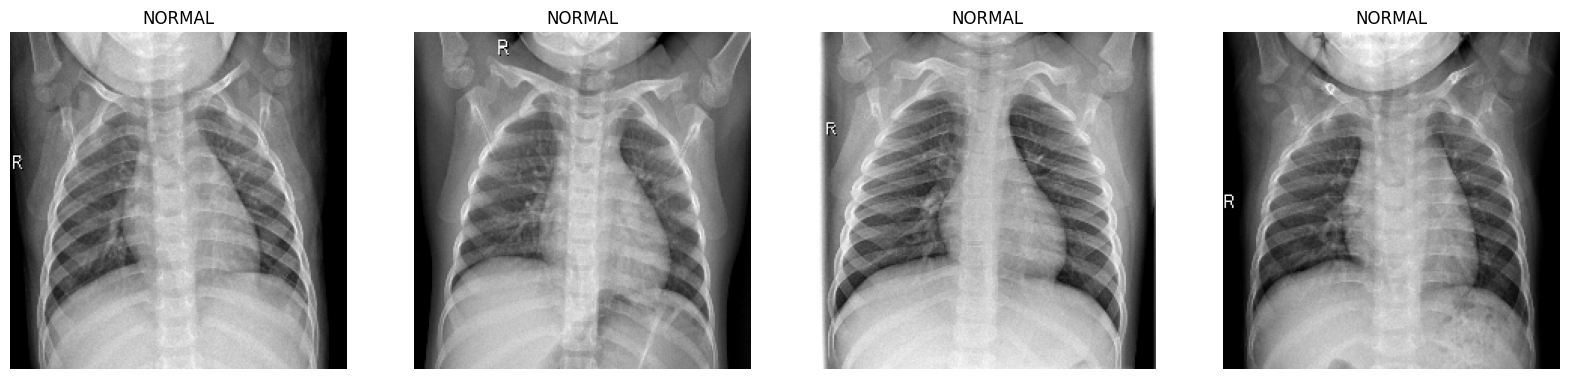

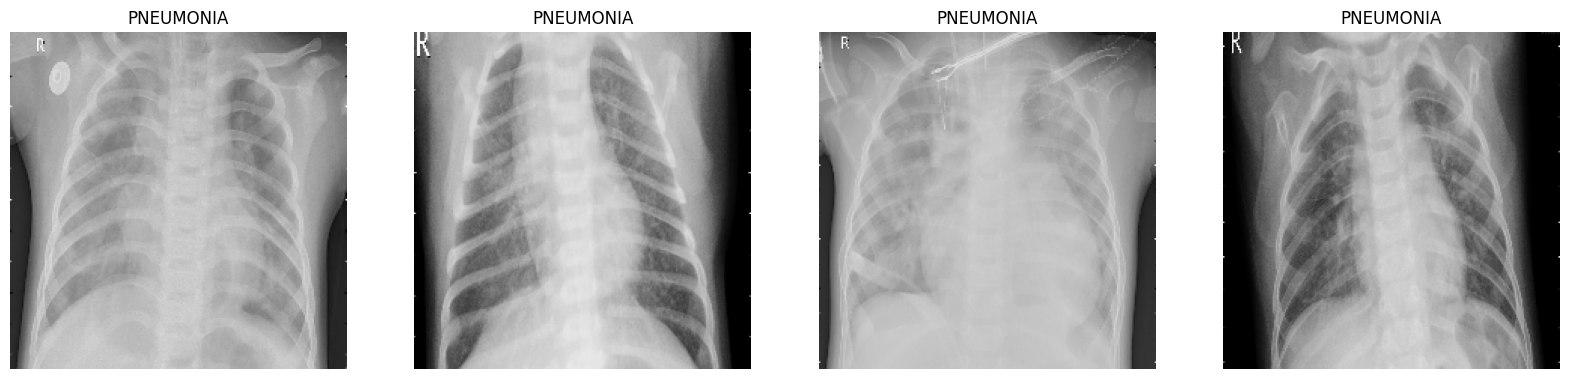

In [10]:
# Display 4 samples from each class
print_images(img_map[img_map['label'] == "NORMAL"].iloc[:4])
print_images(img_map[img_map['label'] == "PNEUMONIA"].iloc[:4])

In [11]:
# Function to count labels
def getLabelCount(frame):
    return frame['label'].value_counts()

label_count = getLabelCount(img_map)
print("Label distribution:")
print(label_count)

Label distribution:
label
PNEUMONIA    4273
NORMAL       1583
Name: count, dtype: int64


## Model Architecture: ResNet-50 + CLIP
Combines ResNet-50 (base model, partially frozen) with CLIP’s ViT-B/32 (VLM, fully frozen). ResNet-50 has 50 layers (conv, batch norm, ReLU, residual blocks). CLIP has an embedding layer and 12 transformer blocks. Features are concatenated and passed through a head: Linear(2048+768->256), ReLU, Linear(256->2). Only ResNet’s last block and the head are trained for efficiency.

In [12]:
# Cell 7: Define ResNet-50 + CLIP model
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models, transforms
from transformers import CLIPProcessor, CLIPModel
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import torch.nn.functional as F

class ResNetCLIPClassifier(nn.Module):
    def __init__(self, num_classes=2, freeze_resnet=True, freeze_clip=True):
        super(ResNetCLIPClassifier, self).__init__()
        # ResNet-50 base
        self.resnet = models.resnet50(pretrained=True)
        resnet_features = self.resnet.fc.in_features
        self.resnet.fc = nn.Identity()  # Remove final FC layer
        
        # Freeze ResNet layers
        if freeze_resnet:
            for param in self.resnet.parameters():
                param.requires_grad = False
            # Unfreeze last block
            for param in self.resnet.layer4.parameters():
                param.requires_grad = True
        
        # CLIP VLM
        self.clip_model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
        self.clip_processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")
        clip_features = self.clip_model.vision_model.config.hidden_size
        
        # Freeze CLIP
        if freeze_clip:
            for param in self.clip_model.parameters():
                param.requires_grad = False
        
        # Combined head
        self.fc1 = nn.Linear(resnet_features + clip_features, 256)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(256, num_classes)
    
    def forward(self, pixel_values):
        # ResNet features
        resnet_out = self.resnet(pixel_values)
        
        # CLIP features
        clip_out = self.clip_model.vision_model(pixel_values=pixel_values).pooler_output
        
        # Concatenate
        combined = torch.cat((resnet_out, clip_out), dim=1)
        
        # Classification head
        x = self.fc1(combined)
        x = self.relu(x)
        x = self.fc2(x)
        return x

# Initialize model
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = ResNetCLIPClassifier(freeze_resnet=True, freeze_clip=True).to(device)
processor = model.clip_processor

# Print model layers
print("Layer Configuration:")
print("- Base Model: ResNet-50 (pre-trained on ImageNet)")
print("  - Conv1 (7x7, 64 filters)")
print("  - BatchNorm, ReLU, MaxPool")
print("  - Layer1: 3 Residual Blocks (Bottleneck: Conv1x1, Conv3x3, Conv1x1)")
print("  - Layer2: 4 Residual Blocks")
print("  - Layer3: 6 Residual Blocks")
print("  - Layer4: 3 Residual Blocks (partially trainable)")
print("  - Removed FC layer")
print("- VLM: CLIP ViT-B/32 (frozen)")
print("  - Embedding Layer")
print("  - 12 Transformer Blocks (Multi-Head Attention, LayerNorm, MLP)")
print("  - Pooler")
print("- Combined Head: Linear(2048+768->256), ReLU, Linear(256->2)")
print("- Trainable Parameters:")
for name, param in model.named_parameters():
    if param.requires_grad:
        print(f"  - {name}: {param.shape}")

Layer Configuration:
- Base Model: ResNet-50 (pre-trained on ImageNet)
  - Conv1 (7x7, 64 filters)
  - BatchNorm, ReLU, MaxPool
  - Layer1: 3 Residual Blocks (Bottleneck: Conv1x1, Conv3x3, Conv1x1)
  - Layer2: 4 Residual Blocks
  - Layer3: 6 Residual Blocks
  - Layer4: 3 Residual Blocks (partially trainable)
  - Removed FC layer
- VLM: CLIP ViT-B/32 (frozen)
  - Embedding Layer
  - 12 Transformer Blocks (Multi-Head Attention, LayerNorm, MLP)
  - Pooler
- Combined Head: Linear(2048+768->256), ReLU, Linear(256->2)
- Trainable Parameters:
  - resnet.layer4.0.conv1.weight: torch.Size([512, 1024, 1, 1])
  - resnet.layer4.0.bn1.weight: torch.Size([512])
  - resnet.layer4.0.bn1.bias: torch.Size([512])
  - resnet.layer4.0.conv2.weight: torch.Size([512, 512, 3, 3])
  - resnet.layer4.0.bn2.weight: torch.Size([512])
  - resnet.layer4.0.bn2.bias: torch.Size([512])
  - resnet.layer4.0.conv3.weight: torch.Size([2048, 512, 1, 1])
  - resnet.layer4.0.bn3.weight: torch.Size([2048])
  - resnet.layer4.0.

## Custom Dataset
Defines a PyTorch Dataset to load X-ray images and labels, processed via CLIP’s processor for model input.

In [13]:
# Cell 8: Custom Dataset class
from PIL import Image
class XRayDataset(Dataset):
    def __init__(self, dataframe, processor, label_map={"NORMAL": 0, "PNEUMONIA": 1}):
        self.dataframe = dataframe
        self.processor = processor
        self.label_map = label_map
    
    def __len__(self):
        return len(self.dataframe)
    
    def __getitem__(self, idx):
        img_path = self.dataframe.iloc[idx]['path']
        label = self.dataframe.iloc[idx]['label']
        
        try:
            img = Image.open(img_path).convert('RGB')
            inputs = self.processor(images=img, return_tensors="pt", padding=True)
            pixel_values = inputs['pixel_values'].squeeze(0)  # [3, 224, 224]
            label_id = self.label_map[label]
            return pixel_values, label_id
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            raise e

## Data Scarcity Analysis
Trains ResNet-50 + CLIP on subsets (30, 100, 500, 1000, 2000, 3000). Subsets up to 2,682 are balanced; larger ones use 1,341 Normal images. Evaluated on 624 test images with accuracy and F1-score.

In [14]:
# Cell 9: Data scarcity analysis
subset_sizes = [30, 100, 500, 1000, 2000]
results = {'size': [], 'accuracy': [], 'f1_score': []}
label_map = {"NORMAL": 0, "PNEUMONIA": 1}

# Test dataset
test_df = img_map[img_map['path'].str.contains('test')]
test_dataset = XRayDataset(test_df, processor, label_map)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

def train_model(model, train_loader, num_epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for pixel_values, labels in train_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(pixel_values)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    return model

def evaluate_model(model, data_loader):
    model.eval()
    preds, trues = [], []
    with torch.no_grad():
        for pixel_values, labels in data_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            outputs = model(pixel_values)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
            trues.extend(labels.cpu().numpy())
    return np.array(preds), np.array(trues)



In [15]:
for size in subset_sizes:
    print(f"\nTraining with {size} samples...")
    # Balance classes up to 2,682
    if size <= 2682:
        normal_samples = img_map[img_map['label'] == 'NORMAL'].sample(size//2, random_state=42)
        pneumonia_samples = img_map[img_map['label'] == 'PNEUMONIA'].sample(size//2, random_state=42)
        subset = pd.concat([normal_samples, pneumonia_samples]).sample(frac=1, random_state=42)
    else:
        normal_samples = img_map[img_map['label'] == 'NORMAL'].sample(1341, random_state=42)
        pneumonia_samples = img_map[img_map['label'] == 'PNEUMONIA'].sample(size - 1341, random_state=42)
        subset = pd.concat([normal_samples, pneumonia_samples]).sample(frac=1, random_state=42)
    
    # Create dataset and loader
    train_dataset = XRayDataset(subset, processor, label_map)
    train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
    
    # Train model
    model = ResNetCLIPClassifier(freeze_resnet=True, freeze_clip=True).to(device)
    model = train_model(model, train_loader, num_epochs=5)
    
    # Evaluate
    preds, trues = evaluate_model(model, test_loader)
    accuracy = np.mean(preds == trues)
    f1 = f1_score(trues, preds, average='weighted')
    
    results['size'].append(size)
    results['accuracy'].append(accuracy)
    results['f1_score'].append(f1)
    print(f"Accuracy: {accuracy:.4f}, F1-Score: {f1:.4f}")
    
    # Clear memory
    torch.cuda.empty_cache() if torch.cuda.is_available() else None



Training with 30 samples...
Epoch 1, Loss: 0.6576
Epoch 2, Loss: 0.4027
Epoch 3, Loss: 0.2461
Epoch 4, Loss: 0.1772
Epoch 5, Loss: 0.0851
Accuracy: 0.8574, F1-Score: 0.8528

Training with 100 samples...
Epoch 1, Loss: 0.5743
Epoch 2, Loss: 0.2327
Epoch 3, Loss: 0.1967
Epoch 4, Loss: 0.0479
Epoch 5, Loss: 0.0250
Accuracy: 0.8413, F1-Score: 0.8347

Training with 500 samples...
Epoch 1, Loss: 0.3624
Epoch 2, Loss: 0.1272
Epoch 3, Loss: 0.0718
Epoch 4, Loss: 0.0481
Epoch 5, Loss: 0.0612
Accuracy: 0.8814, F1-Score: 0.8761

Training with 1000 samples...
Epoch 1, Loss: 0.2817
Epoch 2, Loss: 0.1000
Epoch 3, Loss: 0.0839
Epoch 4, Loss: 0.0952
Epoch 5, Loss: 0.0321
Accuracy: 0.9087, F1-Score: 0.9060

Training with 2000 samples...
Epoch 1, Loss: 0.2560
Epoch 2, Loss: 0.1537
Epoch 3, Loss: 0.0709
Epoch 4, Loss: 0.0504
Epoch 5, Loss: 0.0552
Accuracy: 0.9663, F1-Score: 0.9662


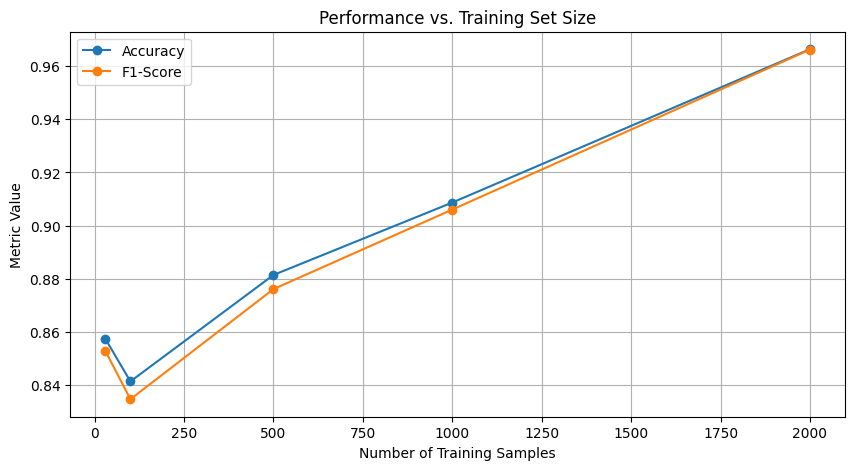

In [16]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(results['size'], results['accuracy'], marker='o', label='Accuracy')
plt.plot(results['size'], results['f1_score'], marker='o', label='F1-Score')
plt.title('Performance vs. Training Set Size')
plt.xlabel('Number of Training Samples')
plt.ylabel('Metric Value')
plt.legend()
plt.grid(True)
plt.show()

## Full Model Training
Trains ResNet-50 + CLIP on 5,216 training images for 10 epochs, with validation on 16 images. Plots accuracy and loss curves.

In [17]:
# Cell 10: Train full model
train_df = img_map[img_map['path'].str.contains('train')]
val_df = img_map[img_map['path'].str.contains('val')]

train_dataset = XRayDataset(train_df, processor, label_map)
val_dataset = XRayDataset(val_df, processor, label_map)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=8, shuffle=False)

# Train model
model = ResNetCLIPClassifier(freeze_resnet=True, freeze_clip=True).to(device)
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

for epoch in range(10):
    model.train()
    train_loss, train_correct = 0.0, 0
    for pixel_values, labels in train_loader:
        pixel_values, labels = pixel_values.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(pixel_values)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        train_correct += (predicted == labels).sum().item()
    
    model.eval()
    val_loss, val_correct = 0.0, 0
    with torch.no_grad():
        for pixel_values, labels in val_loader:
            pixel_values, labels = pixel_values.to(device), labels.to(device)
            outputs = model(pixel_values)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            val_correct += (predicted == labels).sum().item()
    
    history['train_loss'].append(train_loss / len(train_loader))
    history['train_acc'].append(train_correct / len(train_dataset))
    history['val_loss'].append(val_loss / len(val_loader))
    history['val_acc'].append(val_correct / len(val_dataset))
    print(f"Epoch {epoch+1}, Train Loss: {history['train_loss'][-1]:.4f}, Train Acc: {history['train_acc'][-1]:.4f}, Val Loss: {history['val_loss'][-1]:.4f}, Val Acc: {history['val_acc'][-1]:.4f}")


Epoch 1, Train Loss: 0.1307, Train Acc: 0.9517, Val Loss: 0.4928, Val Acc: 0.8750
Epoch 2, Train Loss: 0.0541, Train Acc: 0.9787, Val Loss: 0.0246, Val Acc: 1.0000
Epoch 3, Train Loss: 0.0236, Train Acc: 0.9931, Val Loss: 0.0591, Val Acc: 0.9375
Epoch 4, Train Loss: 0.0191, Train Acc: 0.9927, Val Loss: 0.0299, Val Acc: 1.0000
Epoch 5, Train Loss: 0.0105, Train Acc: 0.9965, Val Loss: 0.0901, Val Acc: 0.8750
Epoch 6, Train Loss: 0.0077, Train Acc: 0.9971, Val Loss: 0.1360, Val Acc: 0.9375
Epoch 7, Train Loss: 0.0192, Train Acc: 0.9939, Val Loss: 0.0092, Val Acc: 1.0000
Epoch 8, Train Loss: 0.0132, Train Acc: 0.9958, Val Loss: 0.0041, Val Acc: 1.0000
Epoch 9, Train Loss: 0.0140, Train Acc: 0.9950, Val Loss: 0.0340, Val Acc: 1.0000
Epoch 10, Train Loss: 0.0031, Train Acc: 0.9988, Val Loss: 0.0014, Val Acc: 1.0000


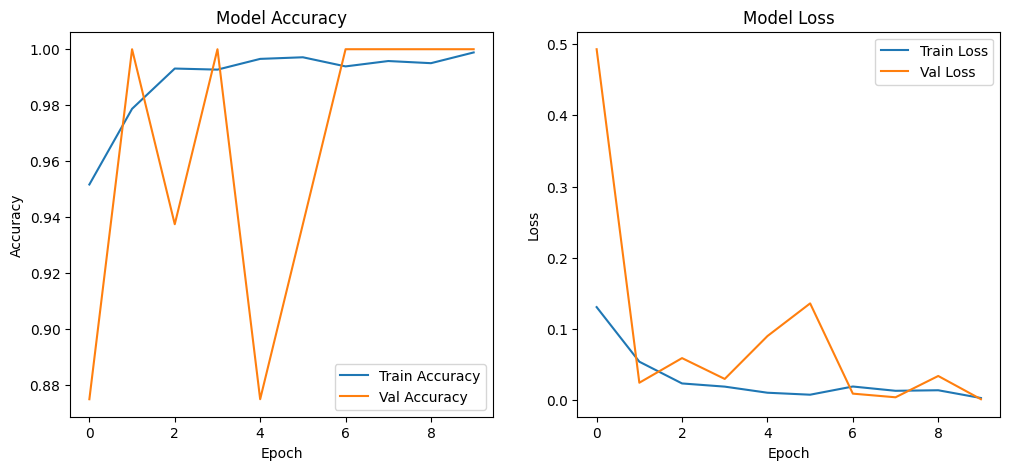

In [18]:
# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_acc'], label='Train Accuracy')
plt.plot(history['val_acc'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [19]:
# Save model
torch.save(model.state_dict(), 'resnet_clip_model.pth')

## Model Evaluation
Evaluates ResNet-50 + CLIP on 624 test images. Outputs a classification report and confusion matrix heatmap.


Classification Report for ResNet-50 + CLIP Model:
              precision    recall  f1-score   support

      NORMAL       1.00      0.50      0.67       234
   PNEUMONIA       0.77      1.00      0.87       390

    accuracy                           0.81       624
   macro avg       0.88      0.75      0.77       624
weighted avg       0.86      0.81      0.79       624



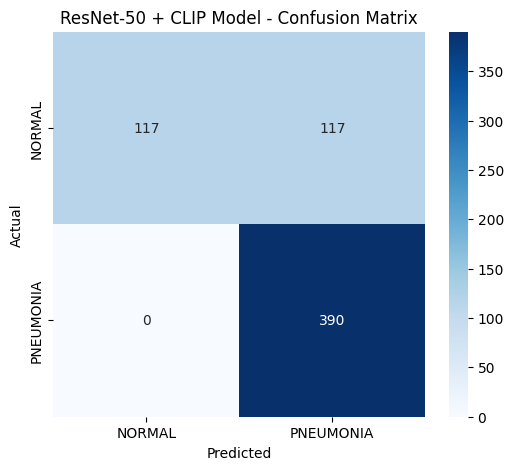

In [20]:
# Cell 11: Model evaluation
test_dataset = XRayDataset(test_df, processor, label_map)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

preds, trues = evaluate_model(model, test_loader)
CATEGORIES = ['NORMAL', 'PNEUMONIA']

# Classification report
print("\nClassification Report for ResNet-50 + CLIP Model:")
print(classification_report(trues, preds, target_names=CATEGORIES))

# Confusion matrix
cm = confusion_matrix(trues, preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CATEGORIES, yticklabels=CATEGORIES)
plt.title("ResNet-50 + CLIP Model - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

## Grad-CAM and Saliency Map Visualization
Uses Grad-CAM to highlight regions in 4 test images (2 Normal, 2 Pneumonia) influencing predictions. Saliency Maps show pixel-level importance. Visualizations focus on lung areas.

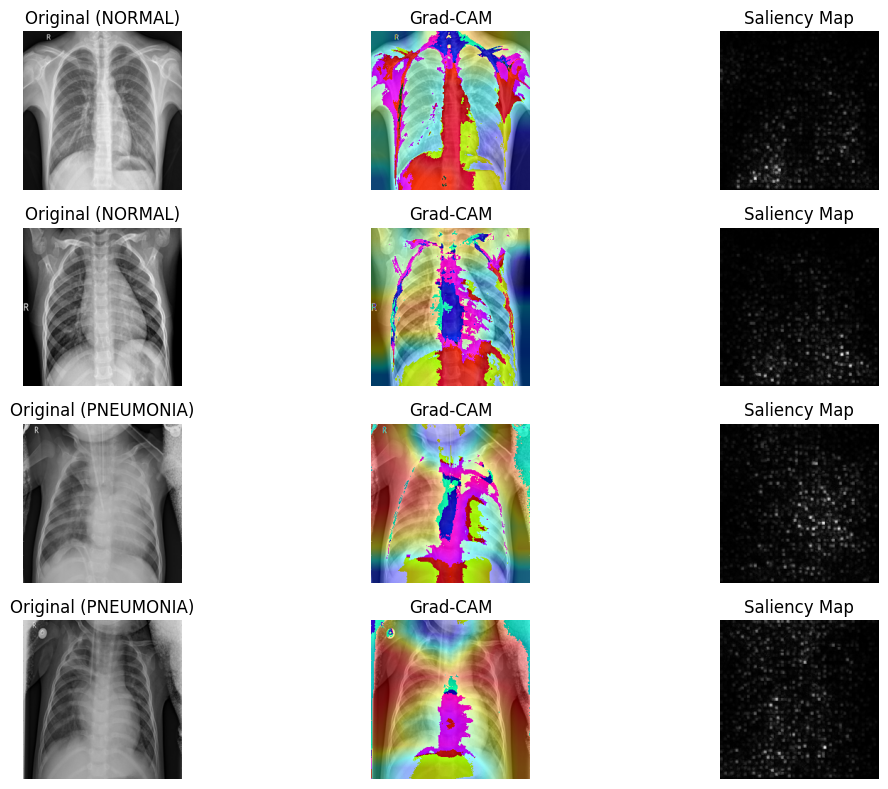

In [25]:
# Cell 12: Grad-CAM and Saliency Map visualization
def get_gradcam_heatmap(model, pixel_values, target_class=None):
    model.eval()
    pixel_values = pixel_values.to(device)
    pixel_values.requires_grad_()
    
    # Forward pass
    outputs = model(pixel_values)
    if target_class is None:
        target_class = outputs.argmax(dim=1).item()  # Single image
    
    model.zero_grad()
    outputs[:, target_class].backward()
    
    # Get gradients
    gradients = pixel_values.grad  # Shape: [1, 3, 224, 224]
    
    # Hook to get activations from layer4
    activations = None
    def hook(module, input, output):
        nonlocal activations
        activations = output
    hook_handle = model.resnet.layer4.register_forward_hook(hook)
    
    # Run forward pass again to capture activations
    model(pixel_values)
    hook_handle.remove()
    
    # Ensure activations and gradients are compatible
    activations = activations[0]  # Shape: [2048, 7, 7]
    pooled_gradients = torch.mean(gradients[0], dim=[1, 2])  # Shape: [3]
    
    # Compute heatmap
    heatmap = torch.zeros(activations.shape[1:], device=device)  # Shape: [7, 7]
    for i in range(activations.shape[0]):  # Iterate over channels (2048)
        heatmap += activations[i] * pooled_gradients.mean()  # Use mean of gradients
    heatmap = F.relu(heatmap)
    heatmap /= torch.max(heatmap) + 1e-8  # Avoid division by zero
    
    return heatmap.detach().cpu().numpy()  # Detach before converting to NumPy

def get_saliency_map(model, pixel_values):
    model.eval()
    pixel_values = pixel_values.to(device)
    pixel_values.requires_grad_()
    
    outputs = model(pixel_values)
    target = outputs.argmax(dim=1)
    model.zero_grad()
    outputs[:, target].backward()
    
    saliency = pixel_values.grad.abs().max(dim=1)[0].cpu().numpy()
    saliency = (saliency - saliency.min()) / (saliency.max() - saliency.min() + 1e-8)
    return saliency[0]

# Select sample images
sample_df = test_df.groupby('label').apply(lambda x: x.sample(2, random_state=42)).reset_index(drop=True)

# Visualize
plt.figure(figsize=(12, 8))
for i, row in sample_df.iterrows():
    img_path = row['path']
    img = Image.open(img_path).convert('RGB')
    inputs = processor(images=img, return_tensors="pt")
    pixel_values = inputs['pixel_values'].to(device)
    
    # Original image (resize to match model input)
    img_resized = img.resize((224, 224))  # Resize to 224x224
    img_np = np.array(img_resized)  # Shape: [224, 224, 3]
    
    # Grad-CAM
    heatmap = get_gradcam_heatmap(model, pixel_values)
    heatmap = cv2.resize(heatmap, (224, 224))  # Shape: [224, 224]
    heatmap = np.uint8(255 * heatmap)  # Shape: [224, 224]
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)  # Shape: [224, 224, 3]
    superimposed_img = heatmap * 0.4 + img_np  # Now compatible: [224, 224, 3]
    
    # Saliency Map
    saliency = get_saliency_map(model, pixel_values)
    saliency = cv2.resize(saliency, (224, 224))  # Shape: [224, 224]
    saliency = np.uint8(255 * saliency)  # Shape: [224, 224]
    
    # Plot
    plt.subplot(4, 3, i*3 + 1)
    plt.imshow(img_np)
    plt.title(f"Original ({row['label']})")
    plt.axis('off')
    
    plt.subplot(4, 3, i*3 + 2)
    plt.imshow(superimposed_img.astype(np.uint8))
    plt.title("Grad-CAM")
    plt.axis('off')
    
    plt.subplot(4, 3, i*3 + 3)
    plt.imshow(saliency, cmap='gray')
    plt.title("Saliency Map")
    plt.axis('off')

plt.tight_layout()
plt.show()

## Summary
Implements a pneumonia classification pipeline:
- **Model**: ResNet-50 (base, last block trainable) + CLIP ViT-B/32 (frozen VLM), with Linear(2048+768->256), ReLU, Linear(256->2).
- **Data Scarcity**: Trained on subsets (30–3000), showing performance trends.
- **Evaluation**: Assessed on 624 test images with classification report and confusion matrix.
- **Visualization**: Grad-CAM and Saliency Maps highlight critical regions.
Optimized for 16GB RAM.